<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Flexão de vigas constituídas por vários materiais

### Problema 1

Uma viga é construída com a secção transversal quadrada (40 mm $\times$ 30 mm) indicada na figura a partir de três barras de dois materiais diferentes colados entre si, aço ($E=$ 210 GPa, $\sigma_\textrm{adm} =$ 355 MPa) e alumínio ($E=70$ GPa, $\sigma_\textrm{adm} =$ 100 MPa). Considere que a viga composta é sujeita à flexão pura em torno do eixo horizontal através da aplicação de momentos positivos nas extremidades.

a) Obtenha a secção homogénea equivalente à secção original.

b) Determine o maior momento fletor admissível na viga composta.

c) Para o momento fletor calculado na alínea b), desenhe a distribuição de tensões normais ao longo do eixo vertical, indicando os seus valores máximos e ainda os valores obtidos na zona de transição entre os dois materiais.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au02/P1/MSII_Au02_P1.png"
width="800"/>

#### Teoria da viga homogénea - Formulário

A teoria da viga homogénea pode ser usada para vigas mistas, constituidas por camadas adjacentes longo da secção de mais do que um material, e com módulos de elasticidade diferentes. Na aplicação deste método é necessário definir uma seção transformada constituída de apenas um material.


##### Vigas compostas por dois ou mais materiais ao longo da sua secção ($i = 2,3,\ldots,m$):

- Razão de módulos:
 
\begin{equation*}
n_i = \frac{E_i}{E_1} 
\end{equation*}

- Posição do centroide da secção:

\begin{equation*}
\overline{y} = \frac{A_1\overline{y}_1 + \sum n_iA_i\overline{y}_i}{A_1 + \sum n_iA_i}
\end{equation*}

- Momento de inércia de aŕea da secção:

\begin{equation*}
I_t = I_1 + \sum n_iI_i
\end{equation*}

- Tensão normal na secção:

\begin{equation*}
\sigma_{x1} = -\frac{My}{I_t} 
\quad\wedge\quad
\sigma_{xi} = -\frac{n_iMy}{I_t} 
\end{equation*}


### Resolução

Considere-se a  viga composta em altura de aço e alumínio com os seguintes dados:

In [2]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa
# Create an empty class
class varin: pass

Aco = varin()
Al = varin()
S = varin()

Aco.E = 210.e3 # MPa
Aco.Sadm = 355. # MPa
Al.E = 70.e3 # MPa
Al.Sadm = 100. # MPa

S.l = 40. # mm
S.h1 = 5. # mm
S.h2 = 5. # mm
S.h3 = 20. # mm
S.h = S.h1 + S.h2 + S.h3
S.A = S.l*S.h
print(f'Section {S.l:.1f} mm x {S.h:.1f} mm > area = {S.A:.1f} mm²')

Section 40.0 mm x 30.0 mm > area = 1200.0 mm²


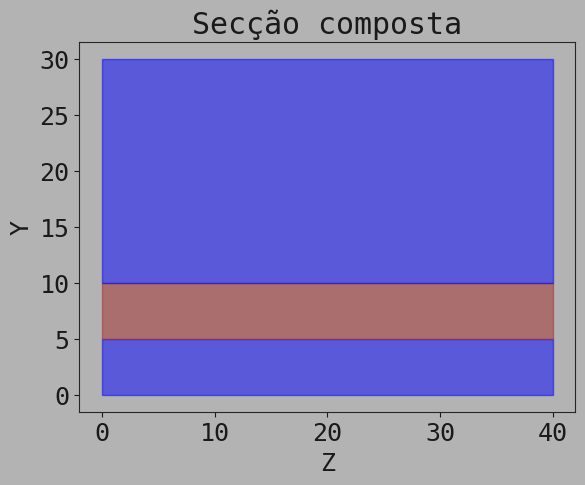

In [3]:
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, 0), S.l, S.h1,color="blue",alpha=0.5))
ax.add_patch(Rectangle((0, S.h1), S.l, S.h2,color="brown",alpha=0.5))
ax.add_patch(Rectangle((0, S.h1+S.h2), S.l, S.h3,color="blue",alpha=0.5))
plt.xlabel("Z")
plt.ylabel("Y")
plt.title("Secção composta")
plt.show()

### Secção homogénea equivalente

É possível utilizar as fórmulas de flexão aplicáveis a materiais homogéneos no contexto de vigas constituídas por diversos materiais (com composição em altura ou em largura), fazendo referência ao conceito de uma viga homogénea equivalente. Esta viga equivalente é obtida ao selecionar um dos materiais e substituir os restantes pelo material escolhido. Naturalmente, para que haja equivalência com base no critério de flexão, é necessário ajustar as dimensões geométricas das áreas transformadas, utilizando um rácio determinado pela relação entre os módulos de elasticidade dos materiais. É importante notar que esse alargamento (se $n > 1$) ou estreitamento (se $n < 1$) deve ocorrer numa direção paralela ao eixo neutro da secção, uma vez que é fundamental manter constante a distância $y$ de cada elemento em relação ao eixo neutro.

Sem perda de generalidade, escolha-se o aço como material de referência. Torna-se assim necessário subtituir a região de alumínio por aço, dando origem a uma secção transformada (homogénea de aço).

### Secção homogéna de aço

Razão de módulos:

\begin{equation*}
n_{i/j} = \frac{E_\textrm{i}}{E_\textrm{j}}
\quad\Rightarrow\quad
n = \frac{E_\textrm{Al}}{E_\textrm{Aco}}
\end{equation*}

In [4]:
S.n = Al.E/Aco.E
print(f'Razão de módulos, n = E.Al / E.Aco = {S.n:.3f}')

Razão de módulos, n = E.Al / E.Aco = 0.333


A geometria da secção composta inicial deve ser alterada para assegurar a equivalência do problema em flexão. A substituição da região de alumínio por aço resulta numa diminuição da secção local (comprimento na direção paralela ao eixo neutro), conforme a razão de módulos:

\begin{equation*}
l_\textrm{Al2Aco} = n \cdot l_\textrm{Al} = \frac{E_\textrm{Al}}{E_\textrm{Aco}} \cdot l_\textrm{Al}
\end{equation*}

In [5]:
S.ln = S.l*S.n
print(f'Original l (Al) : {S.l:.1f} mm > Transformed l (Aco) : {S.ln:.2f} mm')

Original l (Al) : 40.0 mm > Transformed l (Aco) : 13.33 mm


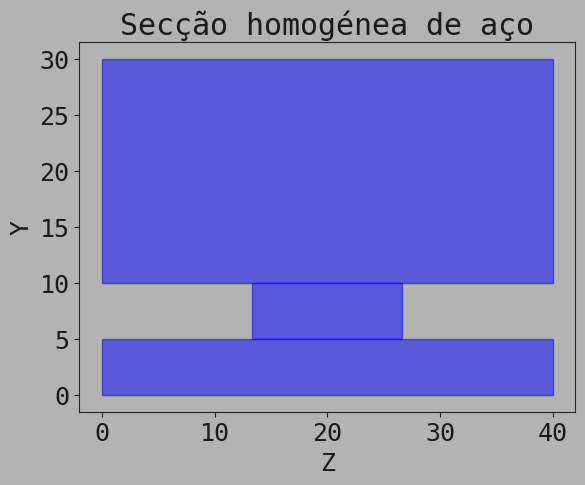

In [6]:
fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, 0), S.l, S.h1,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.l/2-S.ln/2, S.h1), S.ln, S.h2,color="blue",alpha=0.5))
ax.add_patch(Rectangle((0, S.h1+S.h2), S.l, S.h3,color="blue",alpha=0.5))
plt.xlabel("Z")
plt.ylabel("Y")
plt.title("Secção homogénea de aço")
plt.show()

#### Posição do eixo neutro

É fundamental conhecer a posição do eixo neutro, nomeadamente para determinar a distribuição do perfil de tensões.

A secção tranformada tem um plano de simetria vertical, pelo que a abcissa é bem determinada. A posição vertical do centroide, em relação à base da secção por exemplo, deve ser contudo cálculada:

\begin{equation*}
\overline{y} = \sum_i \frac{A_i\overline{y}_i}{A_i}
\quad\Rightarrow\quad
\overline{y} = \frac{\sum_{i=1}^{2} A_\textrm{i}\overline{y}_\textrm{i}\Big|_\textrm{Aco} + n A_\textrm{Al}\overline{y}_\textrm{Al}}{\sum_{i=1}^{2} A_\textrm{i}\Big|_\textrm{Aco} + n A_\textrm{Al}}
\end{equation*}

In [7]:
aco1_A = S.l*S.h1
aco1_yc = S.h1/2
print(f'area 1 (streel 1) : A = {aco1_A:.1f} mm²; yc = {aco1_yc:.1f} mm')

al_A = S.l*S.h2
al_yc = S.h1 + S.h2/2
print(f'area 2 (Al)       : A = {al_A:.1f} mm²; yc = {al_yc:.1f} mm')

print(f'area 2 transf. (Al2streel) : A = {S.n*al_A:.1f} mm²; yc = {al_yc:.1f} mm')

aco2_A = S.l*S.h3
aco2_yc = S.h1 + S.h2 + S.h3/2
print(f'area 3 (streel 2) : A = {aco2_A:.1f} mm²; yc = {aco2_yc:.1f} mm')

print(f'\ncal aux. : (Ay)streel1 = {aco1_A*aco1_yc:.1f} mm²')
print(f'cal aux. : (n*Ay)al2streel = {S.n*al_A*al_yc:.1f} mm²')
print(f'cal aux. : (Ay)streel1 = {aco2_A*aco2_yc:.1f} mm²')

S.trans_yc = (aco1_A*aco1_yc + S.n*al_A*al_yc + aco2_A*aco2_yc)/(aco1_A+S.n*al_A+aco2_A)
print(f'\nyc (transformed section) = {S.trans_yc:.2f} mm')

area 1 (streel 1) : A = 200.0 mm²; yc = 2.5 mm
area 2 (Al)       : A = 200.0 mm²; yc = 7.5 mm
area 2 transf. (Al2streel) : A = 66.7 mm²; yc = 7.5 mm
area 3 (streel 2) : A = 800.0 mm²; yc = 20.0 mm

cal aux. : (Ay)streel1 = 500.0 mm²
cal aux. : (n*Ay)al2streel = 500.0 mm²
cal aux. : (Ay)streel1 = 16000.0 mm²

yc (transformed section) = 15.94 mm


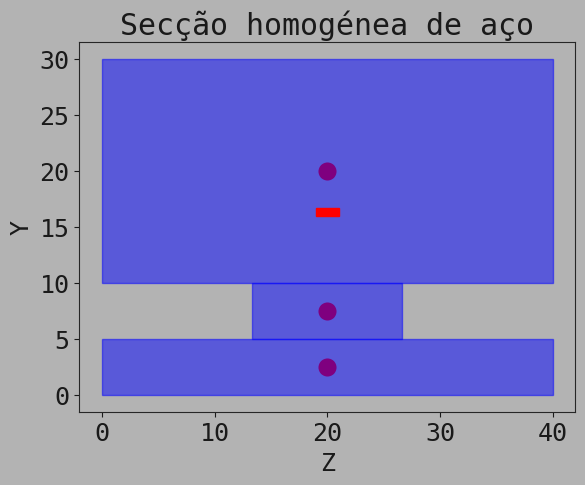

In [16]:
fig, ax = plt.subplots()
ax.scatter([S.l/2,S.l/2,S.l/2],[S.h1/2,S.h1+S.h2/2,S.h1+S.h2+S.h3/2],color="red",marker="o",linewidth=7)
ax.add_patch(Rectangle((0, 0), S.l, S.h1,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.l/2-S.ln/2, S.h1), S.ln, S.h2,color="blue",alpha=0.5))
ax.add_patch(Rectangle((0, S.h1+S.h2), S.l, S.h3,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.l/2+1., S.trans_yc), -2, 0.75,color="red"))
plt.xlabel("Z")
plt.ylabel("Y")
plt.title("Secção homogénea de aço")
plt.show()

#### Momento de inércia

O momento de inércia da secção transformada pode também ser obtido pela combinação linear dos momentos de inércia das regiões elementares da secção:

\begin{equation*}
I_t = \sum_{i=1}^{2}I_\textrm{i}\Big|_{\textrm{aco}} + nI_\textrm{Al} = \underbrace{I_1 + A_1 d_1²}_{\textrm{aco 1}} + \underbrace{n(I_2 + A_2 d_2²)}_{\textrm{Al}} + \underbrace{I_3 + A_3 d_3²}_{\textrm{aco 2}}
\end{equation*}

com

\begin{equation*}
d_1 = |\overline{y}-h_1/2|
\quad\wedge\quad~
d_2 = |\overline{y}-(h_1 + h_2/2)|
\quad\wedge\quad~
d_3 = |\overline{y} -(h_1 + h_2 + h_3/2) |
\end{equation*}

In [9]:
def irect(b,h):
    return b*h**3/12

d1 = S.trans_yc - S.h1/2
print(f'\nd1 = {d1:.2f} mm')
aco1_I = irect(S.l,S.h1) + S.l*S.h1*d1**2
print(f'Iz (streel 1) = {aco1_I:.2f} mm⁴')

d2 = S.trans_yc - (S.h1 + S.h2/2)
print(f'\nd2 = {d2:.2f} mm')
al2steel_I = S.n*(irect(S.l,S.h2) + S.l*S.h2*d2**2)
print(f'Iz (al2steel) = {al2steel_I:.2f} mm⁴')

d3 = np.abs(S.trans_yc - (S.h1 + S.h2 + S.h3/2))
print(f'\nd3 = {d3:.2f} mm')
aco2_I = irect(S.l,S.h3) + S.l*S.h3*d3**2
print(f'Iz (streel 2) = {aco2_I:.2f} mm⁴')

S.I = aco1_I + al2steel_I + aco2_I
print(f'\nIz (trans. section) = {S.I:.2f} mm⁴ = {S.I*1e-12:.2e} m⁴')


d1 = 13.44 mm
Iz (streel 1) = 36529.95 mm⁴

d2 = 8.44 mm
Iz (al2steel) = 4884.98 mm⁴

d3 = 4.06 mm
Iz (streel 2) = 39869.79 mm⁴

Iz (trans. section) = 81284.72 mm⁴ = 8.13e-08 m⁴


#### b) Determine o maior momento fletor admissível na viga composta.

- Equação de dimensionamento:
 
\begin{equation*}
\sigma_\textrm{adm} \geq | \sigma_x |
\end{equation*}

- Aço:

\begin{equation*}
\sigma_\textrm{adm} \geq \frac{M_f}{I_t}y
\quad\Leftrightarrow\quad~
M_f \leq I_t \frac{\sigma_\textrm{adm}}{y}
\end{equation*}

- Alumínio:

\begin{equation*}
\sigma_\textrm{adm} \geq n\left(\frac{M_f}{I_t}y\right)
\quad\Leftrightarrow\quad~
M_f \leq \left(\frac{I_t}{n}\right)  \frac{\sigma_\textrm{adm}}{y}
\end{equation*}

O momento fletor máximo deve ser avaliado para posições extremas da ordenada $y$ e considerando a tensão de cedência quer do aço quer do alumínio.

- $y$ max no aço:

\begin{equation*}
\frac{\sigma_\textrm{adm}}{y_\textrm{max}}\Big|_\textrm{Aco}
\quad\wedge\quad~
y_\textrm{max} = \mathrm{max}\{\overline{y}_c~,~ h - \overline{y}_c\}
\end{equation*}

In [19]:
aco_ymax = np.max([S.trans_yc,S.h-S.trans_yc])
print(f'\n     ymax (streel) = {aco_ymax:.2f} mm')

aco_sa_ym = Aco.Sadm/aco_ymax
print(f'Sadm/ymax (streel) = {aco_sa_ym:.2f} N.mm')

aco_Mf = aco_sa_ym*S.I
print(f'Mf (streel) = {aco_Mf:.2f} N.mm = {aco_Mf*1e-3:.2f} N.m')


     ymax (streel) = 15.94 mm
Sadm/ymax (streel) = 22.27 N.mm
Mf (streel) = 1810577.34 N.mm = 1810.58 N.m


- $y$ max no alumínio:

\begin{equation*}
\frac{\sigma_\textrm{adm}}{y_\textrm{max}}\Big|_\textrm{Al}
\quad\wedge\quad~
y_\textrm{max} = \mathrm{max}\{|\overline{y}_c-h_1|~,~| (h_1+h_2) - \overline{y}_c|\}
\end{equation*}

In [11]:
al_ymax = np.max([np.abs(S.trans_yc-S.h1),np.abs((S.h1+S.h2)-S.trans_yc)])
print(f'\n     ymax (Al) = {al_ymax:.2f} mm')

al_sa_ym = Al.Sadm/al_ymax
print(f'Sadm/ymax (Al) = {al_sa_ym:.2f} N.mm')

al_Mf = al_sa_ym*S.I/S.n
print(f'Mf (Al) = {al_Mf:.2f} N.mm = {al_Mf*1e-3:.2f} N.m')

print('-------------------')
Mfmxadm = np.min([aco_Mf,al_Mf])
print(f'Mf. max admissible = {Mfmxadm:.2f} N.mm = {Mfmxadm*1e-3:.2f} N.m')
print('-------------------')


     ymax (Al) = 10.94 mm
Sadm/ymax (Al) = 9.14 N.mm
Mf (Al) = 2229523.81 N.mm = 2229.52 N.m
-------------------
Mf. max admissible = 1810577.34 N.mm = 1810.58 N.m
-------------------


In [12]:
def sval(m,i,y): return -m/i*y

# (i) lower position, steel
yminaco = -S.trans_yc
Sminaco = sval(Mfmxadm,S.I,yminaco)
print(f'Steel : y1 = {yminaco:.2f} mm | Smin  = {Sminaco:.2f} MPa')

# (ii) lower position, Al
yminal = -S.trans_yc + S.h1
Sminal = sval(Mfmxadm,S.I,yminal)
print(f'      : y2 = {yminal:.2f} mm | Smin  = {Sminal:.2f} MPa')

# (iii) upper position, Al
ymaxal = -S.trans_yc + S.h1 + S.h2
Smaxal = sval(Mfmxadm,S.I,ymaxal)
print(f'      : y3 = {ymaxal:.2f} mm  | Smax  = {Smaxal:.2f} MPa')

# (iv) upper position, steel
ymaxaco = S.h -S.trans_yc
Smaxaco = sval(Mfmxadm,S.I,ymaxaco)
print(f'      : y4 = {ymaxaco:.2f} mm  | Smax  = {Smaxaco:.2f} MPa')

Steel : y1 = -15.94 mm | Smin  = 355.00 MPa
      : y2 = -10.94 mm | Smin  = 243.63 MPa
      : y3 = -5.94 mm  | Smax  = 132.25 MPa
      : y4 = 14.06 mm  | Smax  = -313.24 MPa


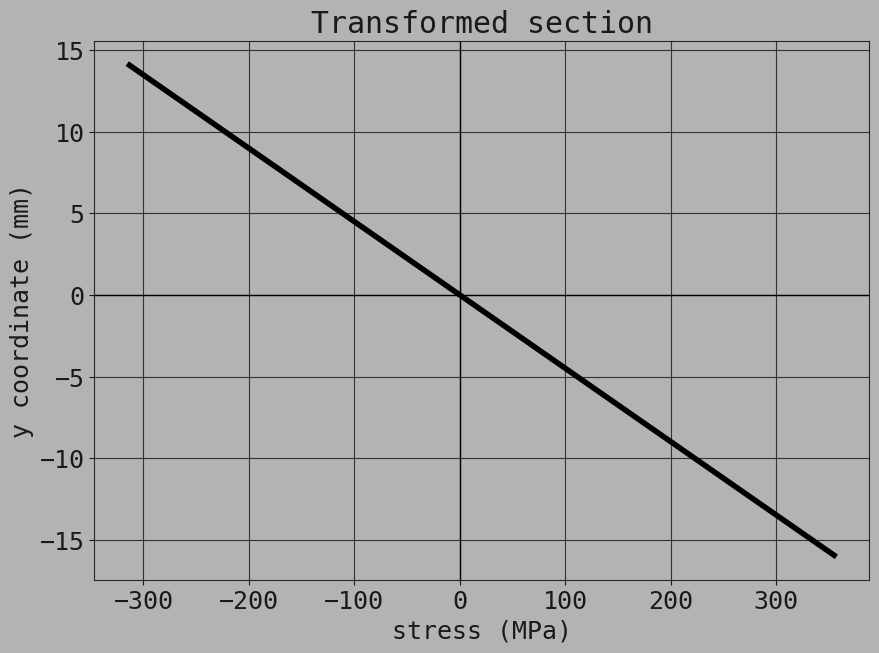

In [13]:
xplo = [yminaco,yminal,ymaxal,ymaxaco]
yplo = [Sminaco,Sminal,Smaxal,Smaxaco]

fz = 15
fig, ax = plt.subplots(figsize=(10,7))
plt.plot(yplo,xplo,'-k', linewidth=4)
plt.xlabel('stress (MPa)')
plt.ylabel('y coordinate (mm)')
plt.title('Transformed section')
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

Steel :    y1 = -15.94 mm | Smin  = 355.00 MPa
Sreel : y2(-) = -10.94 mm | Smin  = 243.63 MPa
Al    : y2(+) = -10.94 mm | Smin  = 81.21 MPa
Al    : y3(-) = -5.94 mm  | Smax  = 44.08 MPa
Steel : y3(+) = -5.94 mm  | Smax  = 132.25 MPa
Steel :    y4 = 14.06 mm  | Smax  = -313.24 MPa


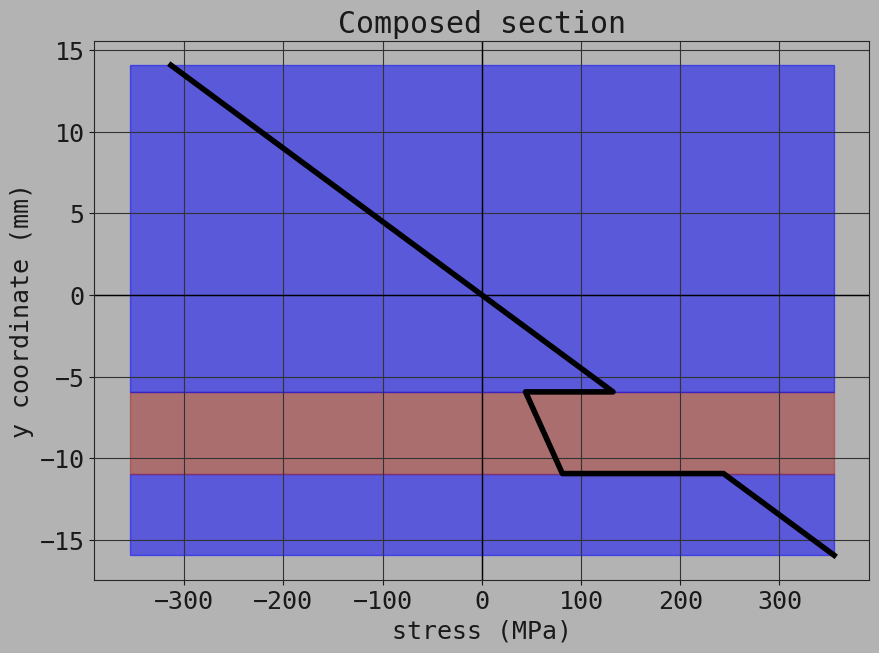

In [21]:
# (ii) lower position, Steel
print(f'Steel :    y1 = {yminaco:.2f} mm | Smin  = {Sminaco:.2f} MPa')

# (ii) lower position, Al
yTminaco = -S.trans_yc + S.h1
STminaco = sval(Mfmxadm,S.I,yTminaco)
print(f'Sreel : y2(-) = {yTminaco:.2f} mm | Smin  = {STminaco:.2f} MPa')
print(f'Al    : y2(+) = {yminal:.2f} mm | Smin  = {S.n*Sminal:.2f} MPa')

# (iii) upper position, Al
print(f'Al    : y3(-) = {ymaxal:.2f} mm  | Smax  = {S.n*Smaxal:.2f} MPa')
yTmaxal = -S.trans_yc + S.h1 + S.h2
STmaxal = sval(Mfmxadm,S.I,yTmaxal)
print(f'Steel : y3(+) = {yTmaxal:.2f} mm  | Smax  = {STmaxal:.2f} MPa')

# (iv) upper position, steel
print(f'Steel :    y4 = {ymaxaco:.2f} mm  | Smax  = {Smaxaco:.2f} MPa')

xplo2 = [yminaco,yTminaco,yminal,yTmaxal,ymaxal,ymaxaco]
yplo2 = [Sminaco,STminaco,S.n*Sminal,S.n*Smaxal,STmaxal,Smaxaco]

fig, ax = plt.subplots(figsize=(10,7))
plt.plot(yplo2,xplo2,'-k', linewidth=4)
ax.add_patch(Rectangle((-Sminaco, yminaco), 2*Sminaco, S.h1,color="blue",alpha=0.5))
ax.add_patch(Rectangle((-Sminaco, yminal), 2*Sminaco, S.h2,color="brown",alpha=0.5))
ax.add_patch(Rectangle((-Sminaco, ymaxal), 2*Sminaco, S.h3,color="blue",alpha=0.5))
plt.xlabel('stress (MPa)')
plt.ylabel('y coordinate (mm)')
plt.title('Composed section')
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>